# Geometric Brownian Motion: Simulating Asset Prices

---

## Project Overview

This notebook simulates future stock price paths for **SanDisk (SNDK)** and **ASML Holding (ASML)** using **Geometric Brownian Motion (GBM)** — the mathematical engine behind the Black-Scholes options pricing model.

### What We Cover
1. Introduction to Brownian Motion and the Wiener process
2. From random walks to Geometric Brownian Motion
3. Estimating drift (μ) and volatility (σ) from real market data
4. Monte Carlo simulation of stock price paths
5. Black-Scholes European call option pricing
6. Comparative analysis: SNDK vs ASML

## Part 1: Mathematical Background

### 1.1 Standard Brownian Motion (Wiener Process)

A standard Brownian motion $\{W_t\}_{t \geq 0}$ is a stochastic process satisfying four axioms:

| Property | Description |
|---|---|
| **Initial condition** | $W_0 = 0$ |
| **Independent increments** | $W_t - W_s \perp \mathcal{F}_s$ for $s < t$ |
| **Gaussian increments** | $W_t - W_s \sim \mathcal{N}(0, t-s)$ |
| **Continuous paths** | $t \mapsto W_t$ is continuous almost surely |

### 1.2 Geometric Brownian Motion

A stock price $S_t$ follows GBM if it satisfies the **stochastic differential equation (SDE)**:

$$dS_t = \mu \, S_t \, dt + \sigma \, S_t \, dW_t$$

where:
- $\mu$ = drift (annualised expected return)
- $\sigma$ = volatility (annualised standard deviation of returns)
- $W_t$ = standard Brownian motion (Wiener process)

### 1.3 Closed-Form Solution via Itô's Lemma

Applying **Itô's Lemma** to $f(S_t) = \ln S_t$ and solving the SDE yields:

$$\boxed{S_t = S_0 \, \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]}$$

The $-\frac{\sigma^2}{2}$ term is the **Itô correction** — it arises because the log-return distribution is skewed by the convexity of the exponential function.

### 1.4 Why GBM Models Stock Prices Well

- **Non-negative prices**: The exponential ensures $S_t > 0$ for all $t$
- **Log-normal returns**: Empirically observed in equity markets  
- **Scale-invariance**: Percentage changes, not absolute changes, are modelled
- **Martingale structure**: Under risk-neutral measure — essential for derivatives pricing

In [3]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 31.8 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=f618b7e9679f37ea81d6318bae40bf2a22825a48a87ecb336b6d27851b4a58b1
  Stored in directory: c:\users\gurveer\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   -------------------- -----

## Part 2: Setup and Data

In [4]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ── Market data ─────────────────────────────────────────────────────────────
import yfinance as yf

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif'
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# ── Fetch historical closing prices ─────────────────────────────────────────
# NOTE: SanDisk (SNDK) was acquired by Western Digital in 2016 and delisted.
# We use its full trading history (2000–2016) for a historically grounded simulation.
# ASML Holding (ASML) is an active Dutch semiconductor equipment manufacturer.

TICKERS = {
    'SNDK': {'name': 'SanDisk Corporation',    'color': '#2563EB'},
    'ASML': {'name': 'ASML Holding N.V.',       'color': '#16A34A'},
}

prices = {}
for ticker in TICKERS:
    data = yf.Ticker(ticker)
    hist = data.history(period='max')['Close']
    if len(hist) < 50:
        print(f"⚠️  {ticker}: limited data ({len(hist)} rows). Extending period.")
    prices[ticker] = hist
    print(f"✓  {ticker}: {len(hist)} trading days  "
          f"({hist.index[0].date()} → {hist.index[-1].date()})")

print("\nData fetch complete.")

✓  SNDK: 274 trading days  (2025-02-13 → 2026-03-18)
✓  ASML: 7804 trading days  (1995-03-15 → 2026-03-18)

Data fetch complete.


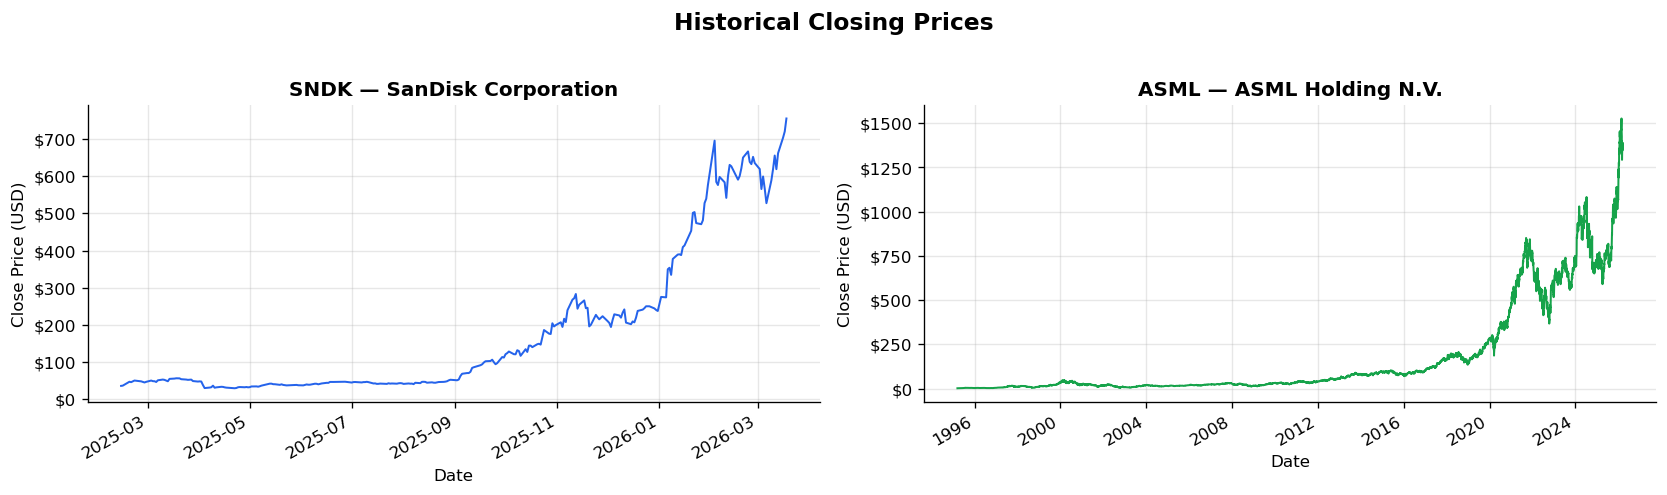

In [6]:
# ── Plot historical closing prices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (ticker, meta) in zip(axes, TICKERS.items()):
    prices[ticker].plot(ax=ax, color=meta['color'], linewidth=1.2)
    ax.set_title(f"{ticker} — {meta['name']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (USD)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

fig.suptitle('Historical Closing Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Estimating GBM Parameters from Data

Under GBM, the log-returns $r_t = \ln(S_t/S_{t-1})$ are i.i.d. normal:

$$r_t \sim \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\!\Delta t,\; \sigma^2 \Delta t\right)$$

We estimate the **annualised** parameters using 252 trading days per year:

$$\hat{\mu} = \bar{r} \times 252 \qquad \hat{\sigma} = s_r \times \sqrt{252}$$

In [8]:
TRADING_DAYS = 252

def estimate_gbm_params(price_series):
    """Compute annualised drift (mu) and volatility (sigma) from daily log-returns."""
    log_returns = np.log(price_series / price_series.shift(1)).dropna()
    mu    = log_returns.mean() * TRADING_DAYS          # annualised drift
    sigma = log_returns.std()  * np.sqrt(TRADING_DAYS) # annualised volatility
    return mu, sigma, log_returns

# ── Compute parameters ──────────────────────────────────────────────────────
params = {}
print(f"{'Ticker':<8} {'μ (ann.)':<14} {'σ (ann.)':<14} {'Last Price':>12}")
print("-" * 52)

for ticker in TICKERS:
    mu, sigma, log_ret = estimate_gbm_params(prices[ticker])
    S0 = float(prices[ticker].iloc[-1])
    params[ticker] = {'mu': mu, 'sigma': sigma, 'S0': S0, 'log_returns': log_ret}
    print(f"{ticker:<8} {mu:>8.4f} ({mu*100:+.2f}%)   {sigma:>8.4f} ({sigma*100:.2f}%)   ${S0:>9.2f}")

Ticker   μ (ann.)       σ (ann.)         Last Price
----------------------------------------------------
SNDK       2.8092 (+280.92%)     0.9882 (98.82%)   $   755.11
ASML       0.2147 (+21.47%)     0.4803 (48.03%)   $  1363.60


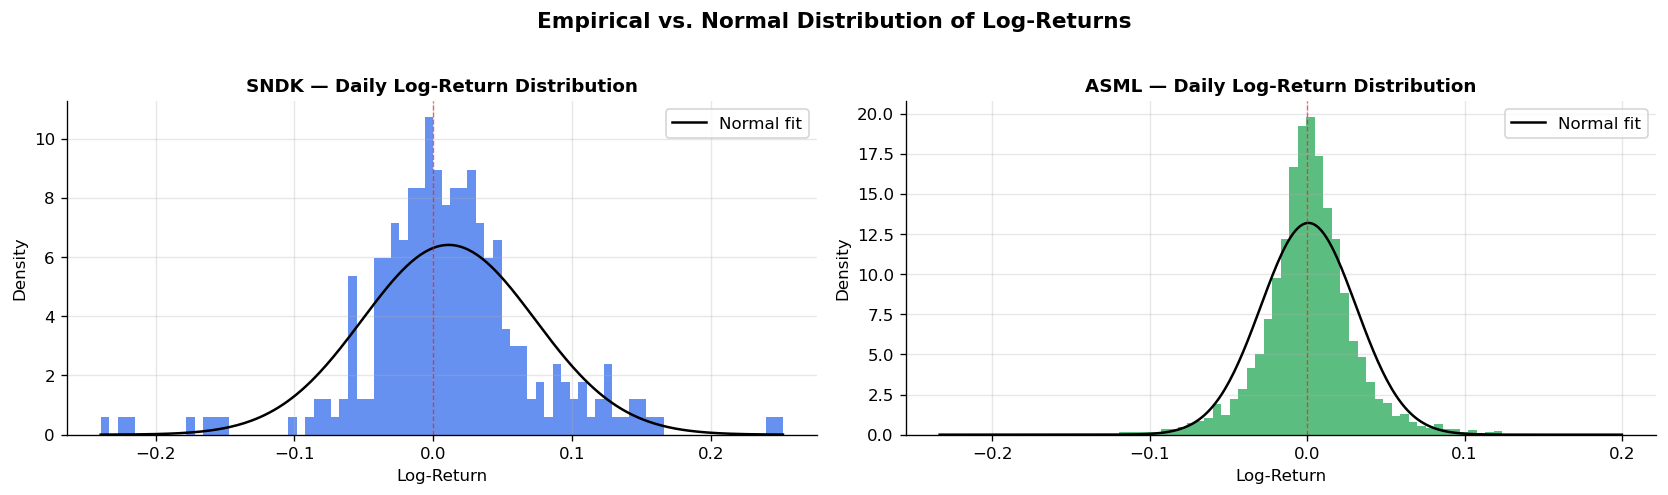

In [9]:
# ── Distribution of log-returns ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (ticker, meta) in zip(axes, TICKERS.items()):
    lr = params[ticker]['log_returns']
    ax.hist(lr, bins=80, color=meta['color'], alpha=0.7, density=True, edgecolor='none')

    # Overlay fitted normal curve
    x = np.linspace(lr.min(), lr.max(), 300)
    ax.plot(x, norm.pdf(x, lr.mean(), lr.std()), 'k-', lw=1.5, label='Normal fit')

    ax.set_title(f"{ticker} — Daily Log-Return Distribution", fontsize=11, fontweight='bold')
    ax.set_xlabel('Log-Return')
    ax.set_ylabel('Density')
    ax.legend()
    ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)

fig.suptitle('Empirical vs. Normal Distribution of Log-Returns', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 4: Monte Carlo Simulation

We discretise the GBM solution over daily steps:

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\; Z_t\right], \quad Z_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, 1)$$

Each independent sample path represents one possible future scenario.

In [10]:
def simulate_gbm(S0, mu, sigma, T=3, N_days=None, M=500, seed=42):
    """
    Simulate M paths of Geometric Brownian Motion.

    Parameters
    ----------
    S0     : float  — Initial stock price
    mu     : float  — Annualised drift
    sigma  : float  — Annualised volatility
    T      : float  — Time horizon in years
    N_days : int    — Number of time steps (default: T * 252)
    M      : int    — Number of Monte Carlo paths
    seed   : int    — Random seed for reproducibility

    Returns
    -------
    paths  : ndarray, shape (N_days+1, M)
    """
    rng    = np.random.default_rng(seed)
    N_days = N_days or int(T * TRADING_DAYS)
    dt     = T / N_days

    # Draw standard normal shocks: shape (N_days, M)
    Z = rng.standard_normal((N_days, M))

    # Daily log-return increment
    daily_return = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    # Prepend initial price and take cumulative product along time axis
    paths = np.vstack([np.full((1, M), S0), S0 * daily_return.cumprod(axis=0)])
    return paths

In [11]:
# ── Simulation parameters ────────────────────────────────────────────────────
T_YEARS = 3    # forecast horizon
N_PATHS = 500  # number of Monte Carlo paths

simulations = {}
for ticker, p in params.items():
    paths = simulate_gbm(S0=p['S0'], mu=p['mu'], sigma=p['sigma'],
                         T=T_YEARS, M=N_PATHS)
    simulations[ticker] = paths
    print(f"{ticker}: simulated {N_PATHS} paths over {T_YEARS} years  "
          f"(shape: {paths.shape})")

print("\nSimulation complete.")

SNDK: simulated 500 paths over 3 years  (shape: (757, 500))
ASML: simulated 500 paths over 3 years  (shape: (757, 500))

Simulation complete.


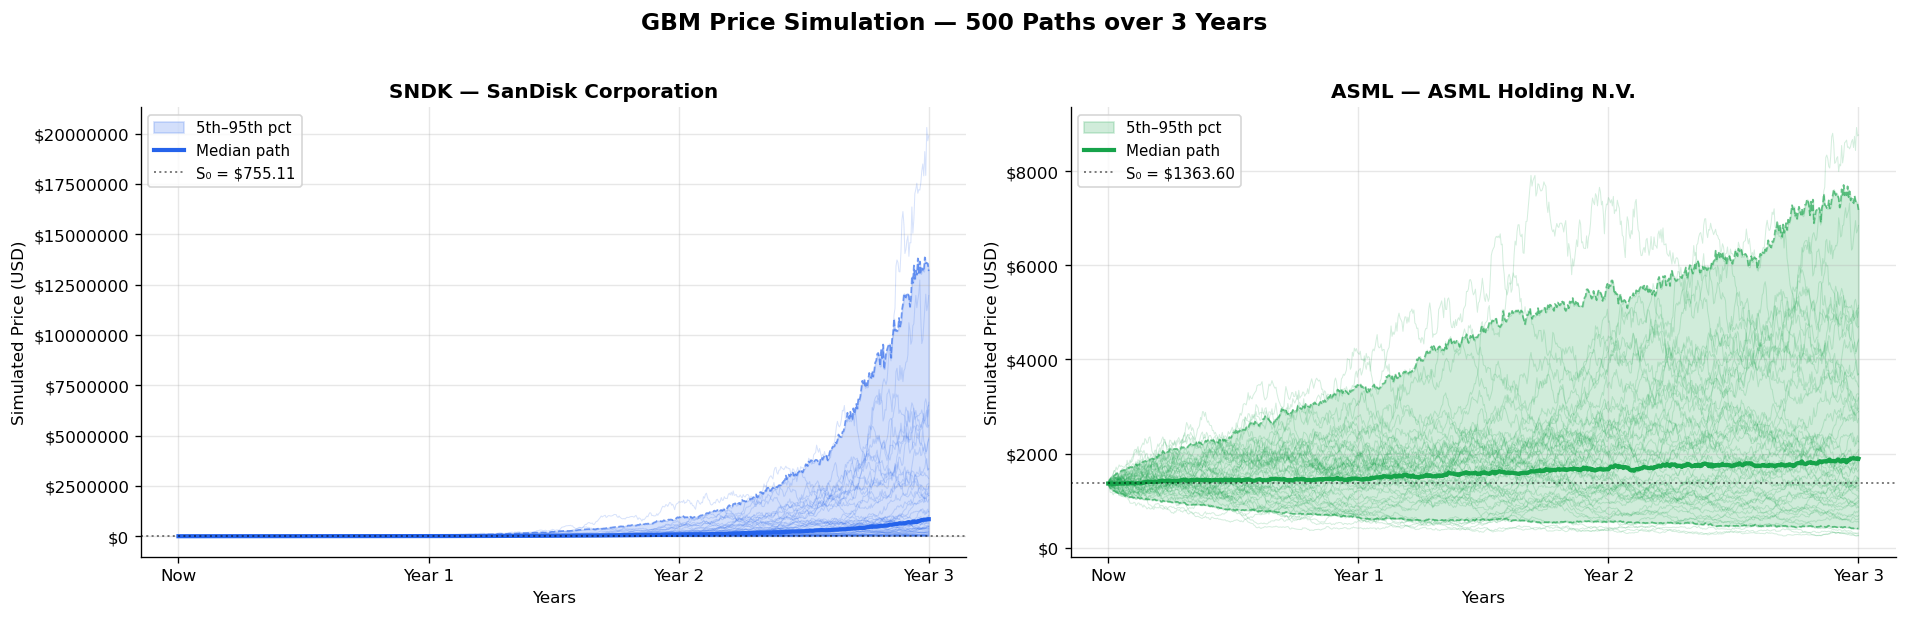

In [12]:
# ── Plot simulated price paths ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

years = np.linspace(0, T_YEARS, simulations['SNDK'].shape[0])

for ax, (ticker, meta) in zip(axes, TICKERS.items()):
    paths = simulations[ticker]
    color = meta['color']

    # Draw 50 paths for clarity
    ax.plot(years, paths[:, :50], alpha=0.18, color=color, linewidth=0.6)

    # 5th, 50th, 95th percentile bands
    p5, p50, p95 = np.percentile(paths, [5, 50, 95], axis=1)
    ax.fill_between(years, p5, p95, alpha=0.2, color=color, label='5th–95th pct')
    ax.plot(years, p50, color=color, lw=2.5, label='Median path')
    ax.plot(years, p5,  color=color, lw=1,   ls='--', alpha=0.6)
    ax.plot(years, p95, color=color, lw=1,   ls='--', alpha=0.6)

    ax.axhline(params[ticker]['S0'], color='black', ls=':', lw=1.2, alpha=0.5,
               label=f'S₀ = ${params[ticker]["S0"]:.2f}')

    ax.set_title(f"{ticker} — {meta['name']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Years')
    ax.set_ylabel('Simulated Price (USD)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Now', 'Year 1', 'Year 2', 'Year 3'])
    ax.legend(fontsize=9)

fig.suptitle(f'GBM Price Simulation — {N_PATHS} Paths over {T_YEARS} Years',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

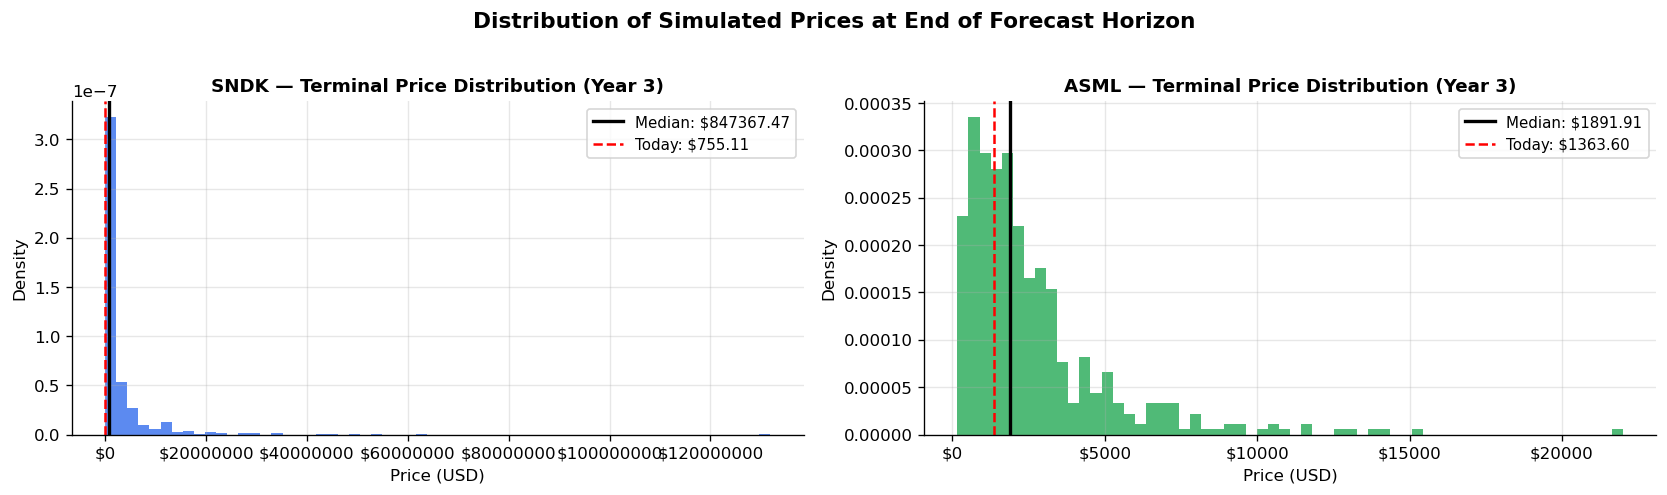

Ticker         Mean     Median    5th pct   95th pct    Prob > S₀
----------------------------------------------------------------
SNDK     $3341489.17 $847367.47 $ 35390.56 $13171799.05      100.0%
ASML     $  2621.10 $  1891.91 $   404.22 $  7177.89       64.8%


In [13]:
# ── Terminal price distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (ticker, meta) in zip(axes, TICKERS.items()):
    terminal = simulations[ticker][-1, :]  # final prices across all paths
    S0 = params[ticker]['S0']

    ax.hist(terminal, bins=60, color=meta['color'], alpha=0.75,
            density=True, edgecolor='none')
    ax.axvline(np.median(terminal), color='black', lw=2, label=f'Median: ${np.median(terminal):.2f}')
    ax.axvline(S0, color='red', ls='--', lw=1.5, label=f'Today: ${S0:.2f}')

    ax.set_title(f"{ticker} — Terminal Price Distribution (Year {T_YEARS})",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Density')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.legend(fontsize=9)

fig.suptitle('Distribution of Simulated Prices at End of Forecast Horizon',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"{'Ticker':<8} {'Mean':>10} {'Median':>10} {'5th pct':>10} {'95th pct':>10} {'Prob > S₀':>12}")
print("-" * 64)
for ticker in TICKERS:
    terminal = simulations[ticker][-1, :]
    S0 = params[ticker]['S0']
    prob_up = np.mean(terminal > S0)
    print(f"{ticker:<8} ${np.mean(terminal):>9.2f} ${np.median(terminal):>9.2f} "
          f"${np.percentile(terminal, 5):>9.2f} ${np.percentile(terminal, 95):>9.2f} "
          f"{prob_up:>11.1%}")

## Part 5: Black-Scholes Option Pricing

GBM is the foundation of the **Black-Scholes-Merton (BSM)** model. Under a risk-neutral measure, the fair value of a **European call option** is:

$$C = S_0 \, \Phi(d_+) - K \, e^{-rT} \, \Phi(d_-)$$

$$d_{\pm} = \frac{\ln(S_0/K) + \left(r \pm \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

| Symbol | Meaning |
|--------|--------|
| $S_0$ | Current stock price |
| $K$ | Strike price |
| $r$ | Risk-free interest rate |
| $T$ | Time to expiry (years) |
| $\sigma$ | Implied / historical volatility |
| $\Phi$ | CDF of the standard normal distribution |

In [14]:
def black_scholes_call(S0, K, r, sigma, T):
    """
    Compute BSM European call option price.

    Parameters
    ----------
    S0    : float — Current stock price
    K     : float — Strike price
    r     : float — Risk-free rate (annual)
    sigma : float — Annualised volatility
    T     : float — Time to expiry (years)

    Returns
    -------
    call_price : float
    delta      : float — Option delta (∂C/∂S)
    """
    d_plus  = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d_minus = d_plus - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d_plus) - K * np.exp(-r * T) * norm.cdf(d_minus)
    delta      = norm.cdf(d_plus)  # sensitivity to underlying price
    return call_price, delta


# ── Price at-the-money (ATM) calls for both tickers ──────────────────────────
RISK_FREE_RATE = 0.05  # 5% — approximate US 1-yr Treasury yield

print("Black-Scholes European Call Option Prices")
print("=" * 62)

for ticker in TICKERS:
    S0    = params[ticker]['S0']
    sigma = params[ticker]['sigma']

    print(f"\n{ticker}  |  S₀ = ${S0:.2f}  |  σ = {sigma*100:.1f}%  |  r = {RISK_FREE_RATE*100:.1f}%")
    print(f"  {'Strike (K)':<14} {'T = 0.5 yr':>14} {'T = 1 yr':>14} {'T = 2 yr':>14}")
    print(f"  {'-'*58}")

    for K_factor in [0.90, 1.00, 1.10]:
        K = S0 * K_factor
        label = f"${K:.2f} ({'OTM' if K_factor > 1 else 'ATM' if K_factor == 1 else 'ITM'})"
        prices_row = []
        for T in [0.5, 1.0, 2.0]:
            c, _ = black_scholes_call(S0, K, RISK_FREE_RATE, sigma, T)
            prices_row.append(f"${c:>9.2f}")
        print(f"  {label:<14} {'  '.join(prices_row)}")

Black-Scholes European Call Option Prices

SNDK  |  S₀ = $755.11  |  σ = 98.8%  |  r = 5.0%
  Strike (K)         T = 0.5 yr       T = 1 yr       T = 2 yr
  ----------------------------------------------------------
  $679.60 (ITM)  $   243.05  $   322.77  $   426.29
  $755.11 (ATM)  $   213.20  $   297.78  $   407.33
  $830.62 (OTM)  $   187.35  $   275.42  $   389.97

ASML  |  S₀ = $1363.60  |  σ = 48.0%  |  r = 5.0%
  Strike (K)         T = 0.5 yr       T = 1 yr       T = 2 yr
  ----------------------------------------------------------
  $1227.24 (ITM) $   268.37  $   350.45  $   469.72
  $1363.60 (ATM) $   198.91  $   287.06  $   413.73
  $1499.96 (OTM) $   144.92  $   234.32  $   364.85


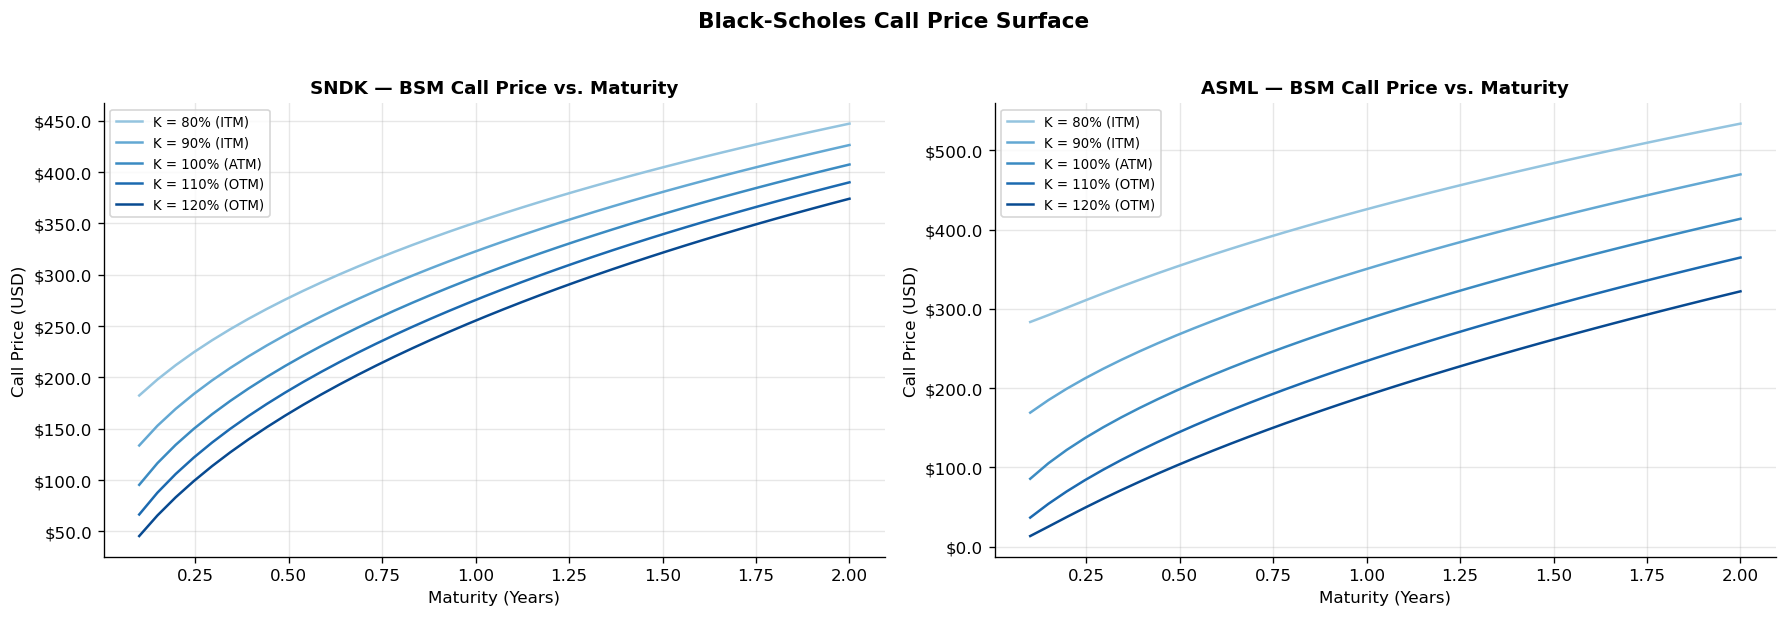

In [15]:
# ── Call price surface as a function of strike and maturity ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

maturities = np.linspace(0.1, 2.0, 40)
strike_factors = [0.80, 0.90, 1.00, 1.10, 1.20]

for ax, (ticker, meta) in zip(axes, TICKERS.items()):
    S0    = params[ticker]['S0']
    sigma = params[ticker]['sigma']
    colors_local = plt.cm.Blues(np.linspace(0.4, 0.9, len(strike_factors)))

    for K_factor, col in zip(strike_factors, colors_local):
        K = S0 * K_factor
        call_prices = [black_scholes_call(S0, K, RISK_FREE_RATE, sigma, t)[0]
                       for t in maturities]
        moneyness = 'ITM' if K_factor < 1 else 'ATM' if K_factor == 1 else 'OTM'
        ax.plot(maturities, call_prices, color=col,
                label=f'K = {K_factor*100:.0f}% ({moneyness})', lw=1.5)

    ax.set_title(f"{ticker} — BSM Call Price vs. Maturity", fontsize=11, fontweight='bold')
    ax.set_xlabel('Maturity (Years)')
    ax.set_ylabel('Call Price (USD)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1f'))
    ax.legend(fontsize=8)

fig.suptitle('Black-Scholes Call Price Surface', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 6: Comparative Analysis

### SNDK vs ASML — Key Insights

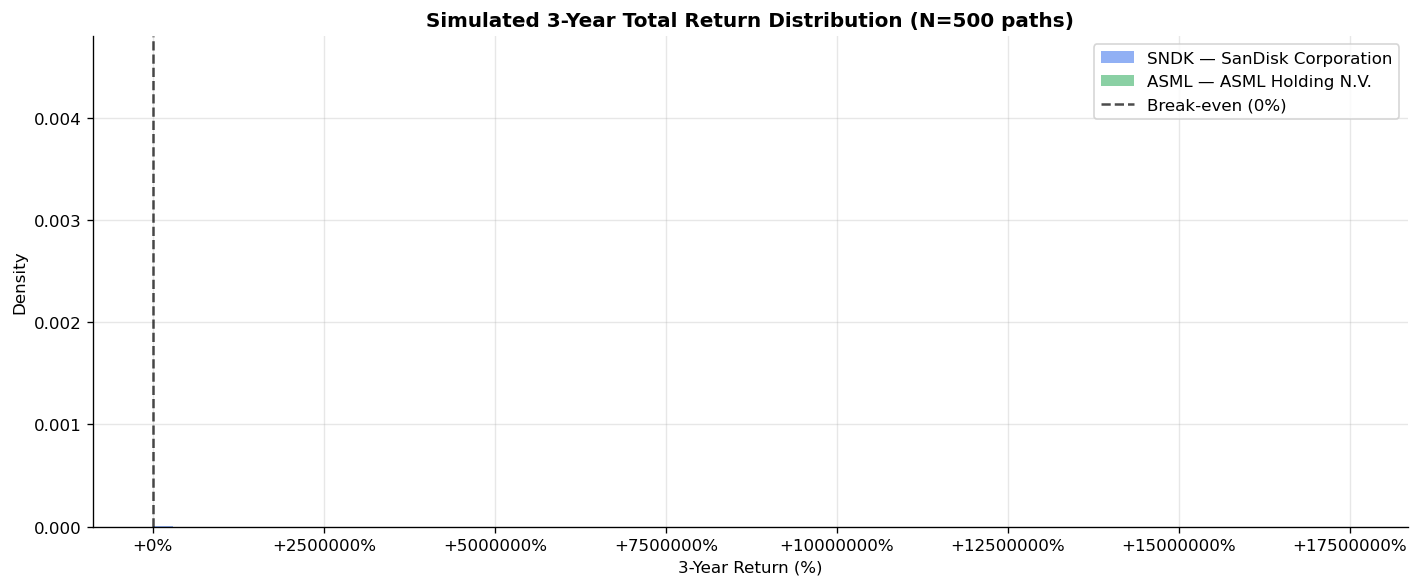


3-Year Forecast Summary
Metric                                     SNDK               ASML
----------------------------------------------------------------------
Annualised Drift (μ)                   +280.92%            +21.47%
Annualised Volatility (σ)                98.82%             48.03%
Current Price (S₀)                      $755.11           $1363.60
Median Simulated Price               $847367.47           $1891.91
Expected Price (Mean)               $3341489.17           $2621.10
5th Percentile Price                  $35390.56            $404.22
95th Percentile Price              $13171799.05           $7177.89
Prob(Price > S₀)                         100.0%              64.8%


In [16]:
# ── Side-by-side comparison of simulated 3-year outcomes ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for ticker, meta in TICKERS.items():
    terminal = simulations[ticker][-1, :]
    S0 = params[ticker]['S0']
    # Plot as percentage return distribution
    pct_returns = (terminal / S0 - 1) * 100
    ax.hist(pct_returns, bins=60, alpha=0.5, color=meta['color'],
            density=True, label=f"{ticker} — {meta['name']}", edgecolor='none')

ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.7, label='Break-even (0%)')
ax.set_title(f'Simulated 3-Year Total Return Distribution (N={N_PATHS} paths)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('3-Year Return (%)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
ax.legend()
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n3-Year Forecast Summary")
print("=" * 70)
print(f"{'Metric':<28} {'SNDK':>18} {'ASML':>18}")
print("-" * 70)

rows = [
    ('Annualised Drift (μ)',         lambda t: f"{params[t]['mu']*100:+.2f}%"),
    ('Annualised Volatility (σ)',     lambda t: f"{params[t]['sigma']*100:.2f}%"),
    ('Current Price (S₀)',            lambda t: f"${params[t]['S0']:.2f}"),
    ('Median Simulated Price',        lambda t: f"${np.median(simulations[t][-1,:]):.2f}"),
    ('Expected Price (Mean)',         lambda t: f"${np.mean(simulations[t][-1,:]):.2f}"),
    ('5th Percentile Price',          lambda t: f"${np.percentile(simulations[t][-1,:], 5):.2f}"),
    ('95th Percentile Price',         lambda t: f"${np.percentile(simulations[t][-1,:],95):.2f}"),
    ('Prob(Price > S₀)',              lambda t: f"{np.mean(simulations[t][-1,:]>params[t]['S0']):.1%}"),
]

for label, fn in rows:
    print(f"{label:<28} {fn('SNDK'):>18} {fn('ASML'):>18}")

## Part 7: Limitations and Extensions

### Limitations of GBM

| Assumption | Reality | Impact |
|---|---|---|
| Constant volatility | Volatility clusters and mean-reverts | Underprices OTM options |
| Continuous paths | Markets can gap (earnings, crises) | Misses jump risk |
| Log-normal returns | Fat tails observed empirically | Underestimates tail events |
| Constant drift | Regimes change over time | Misprices long-dated options |

### Extensions

| Model | Key Feature |
|---|---|
| **Heston (1993)** | Stochastic volatility — $\sigma_t$ follows CIR process |
| **Jump-Diffusion (Merton 1976)** | Adds Poisson jump process to GBM |
| **SABR** | Stochastic α, β, ρ — widely used for vol surface interpolation |
| **Rough Volatility (rBergomi)** | Fractional Brownian motion in volatility |

### Key Takeaway

> Despite its simplifying assumptions, GBM remains the canonical baseline in quantitative finance. Its tractability — yielding closed-form solutions for option prices, deltas, and hedging ratios — makes it indispensable for building intuition before moving to more complex models.

In [17]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         Geometric Brownian Motion — Project Summary          ║
╠══════════════════════════════════════════════════════════════╣
║  Tickers analysed : SNDK (SanDisk), ASML (ASML Holding)     ║
║  Forecast horizon : 3 years                                  ║
║  Monte Carlo paths: 500                                      ║
║  Option model     : Black-Scholes-Merton                     ║
╠══════════════════════════════════════════════════════════════╣
║  Key concepts covered:                                       ║
║  • Wiener process axioms                                     ║
║  • GBM SDE and Itô's Lemma solution                          ║
║  • Parameter estimation from historical data                 ║
║  • Monte Carlo simulation and path visualisation             ║
║  • Black-Scholes call pricing and Greeks (Delta)             ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         Geometric Brownian Motion — Project Summary          ║
╠══════════════════════════════════════════════════════════════╣
║  Tickers analysed : SNDK (SanDisk), ASML (ASML Holding)     ║
║  Forecast horizon : 3 years                                  ║
║  Monte Carlo paths: 500                                      ║
║  Option model     : Black-Scholes-Merton                     ║
╠══════════════════════════════════════════════════════════════╣
║  Key concepts covered:                                       ║
║  • Wiener process axioms                                     ║
║  • GBM SDE and Itô's Lemma solution                          ║
║  • Parameter estimation from historical data                 ║
║  • Monte Carlo simulation and path visualisation             ║
║  • Black-Scholes call pricing and Greeks (Delta)             ║
╚══════════════════════════════════════════════════════════════╝

